## EDA( Exploratory Data Analysis )
 EDA is the process of examining, visualizing, and summarizing a dataset to understand its key characteristics before performing any modeling or advanced analysis.

#### IMPORT LIBRARIES

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### LOAD THE DATASET AND DISPLAY INFORMATION

In [26]:
df = pd.read_csv('C:/Users/divyanshu/OneDrive/Desktop/Projects/ImpactSense/impactsenseAI-Infosys-Intern-project/milestone_2/week_3/Day_13/preprocessed_earthquake_data.csv')

print("Dataset Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109848 entries, 0 to 109847
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   latitude          109848 non-null  float64
 1   longitude         109848 non-null  float64
 2   depth             109848 non-null  float64
 3   mag               109848 non-null  float64
 4   magType           109848 non-null  object 
 5   rms               109848 non-null  float64
 6   type              109848 non-null  object 
 7   status            109848 non-null  object 
 8   Year              109848 non-null  int64  
 9   Month             109848 non-null  int64  
 10  Day               109848 non-null  int64  
 11  Hour              109848 non-null  int64  
 12  Minute            109848 non-null  int64  
 13  Second            109848 non-null  int64  
 14  DayOfWeek         109848 non-null  int64  
 15  Mw                109715 non-null  float64
 16  damage

In [27]:
# Combine separate time components (Year, Month, Day, Hour, Minute, Second) into a single datetime column 

time_cols = ['Year', 'Month', 'Day', 'Hour', 'Minute', 'Second']
available_cols = [col for col in time_cols if col in df.columns]

if {'Year', 'Month', 'Day'}.issubset(df.columns):
    df['datetime'] = pd.to_datetime(df[['Year', 'Month', 'Day']].astype(str).agg('-'.join, axis=1), errors='coerce')
elif 'Date' in df.columns:
    df['datetime'] = pd.to_datetime(df['Date'], errors='coerce')
else:
    raise ValueError("No recognizable time columns found.")

#### Task 1. Temporal Distribution Analysis
Analyze earthquake frequency and magnitude trends over time.


In [28]:
# Earthquake frequency by Year, Month, DayOfWeek
yearly_counts = df['Year'].value_counts().sort_index()
monthly_counts = df['Month'].value_counts()
weekday_counts = df['DayOfWeek'].value_counts()


# Mean magnitude and damage potential by temporal dimensions
df['Year'] = df['datetime'].dt.year
df['Month'] = df['datetime'].dt.month_name()
df['DayOfWeek'] = df['datetime'].dt.day_name()

# Identify magnitude and damage columns
magnitude_col = next((col for col in df.columns if 'mag' in col.lower()), None)
damage_col = next((col for col in df.columns if 'damage_potential' in col.lower()), None)

# --- Frequency analysis ---
yearly_counts = df['Year'].value_counts().sort_index()
monthly_counts = df['Month'].value_counts()[
    ['January','February','March','April','May','June','July','August','September','October','November','December']
]
weekday_counts = df['DayOfWeek'].value_counts()[
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
]

temporal_summary = {}
if magnitude_col:
    temporal_summary['Year'] = df.groupby('Year')[magnitude_col].mean()
    temporal_summary['Month'] = df.groupby('Month')[magnitude_col].mean()
    temporal_summary['DayOfWeek'] = df.groupby('DayOfWeek')[magnitude_col].mean()

if damage_col:
    temporal_summary['Year_damage'] = df.groupby('Year')[damage_col].mean()


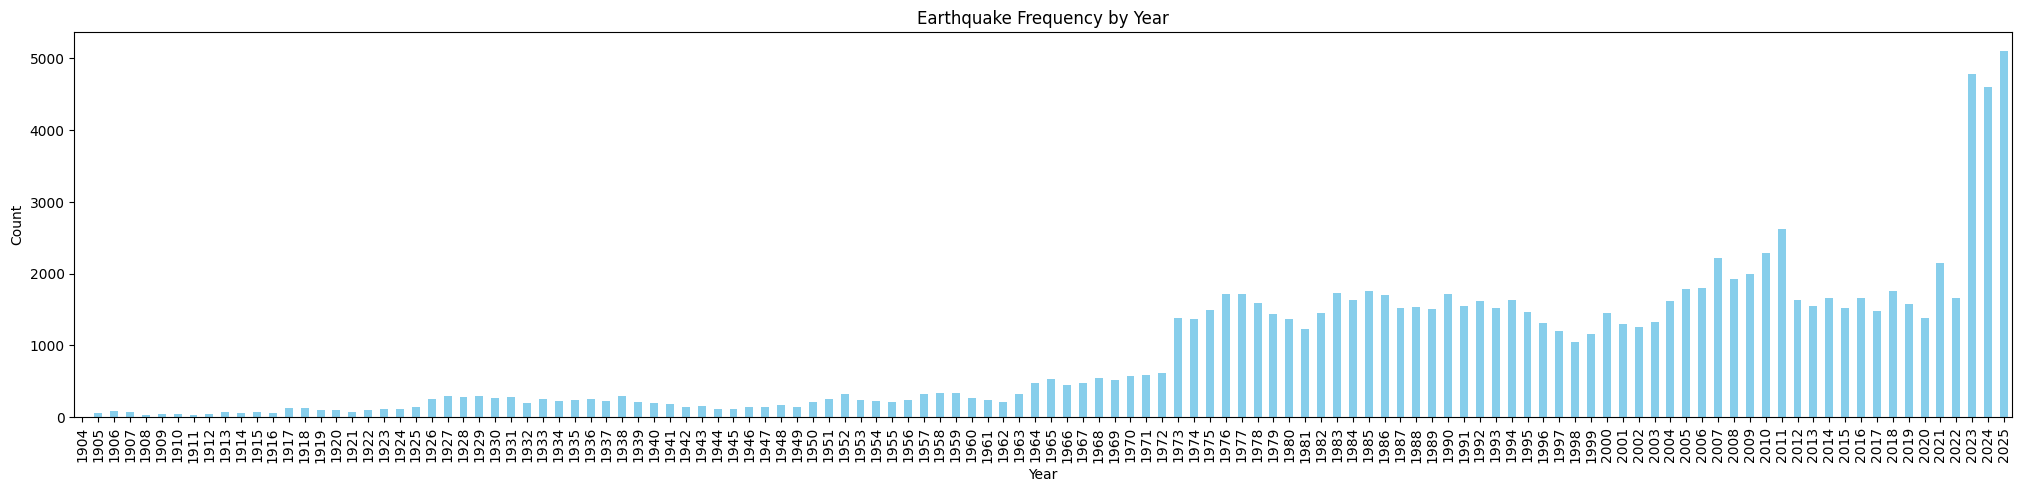

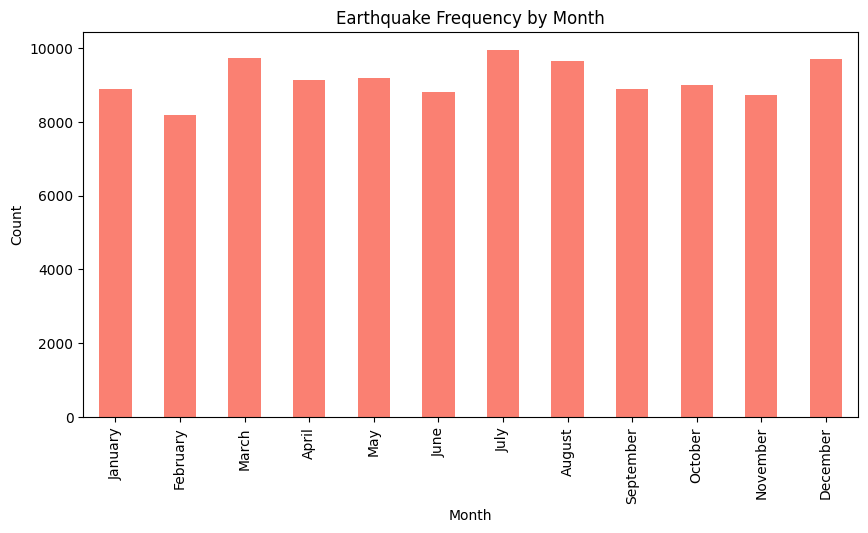

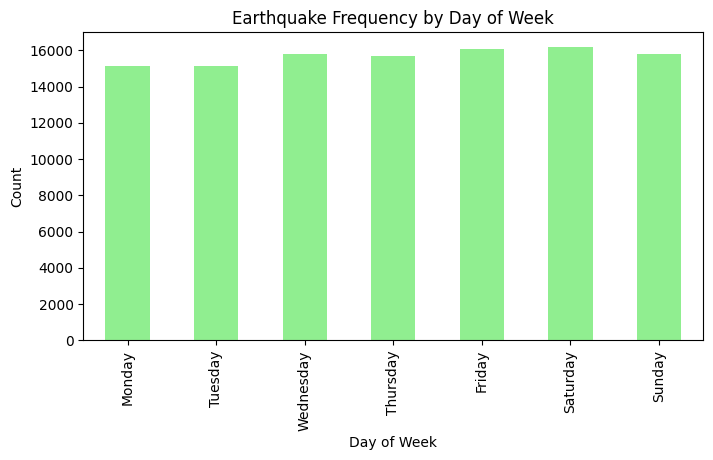

In [29]:
plt.figure(figsize=(25, 5))
yearly_counts.plot(kind='bar', color='skyblue')
plt.title('Earthquake Frequency by Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 5))
month_order = ['January','February','March','April','May','June','July',
               'August','September','October','November','December']
df['Month'].value_counts().reindex(month_order).plot(kind='bar', color='salmon')
plt.title('Earthquake Frequency by Month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8, 4))
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['DayOfWeek'].value_counts().reindex(weekday_order).plot(kind='bar', color='lightgreen')
plt.title('Earthquake Frequency by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.show()

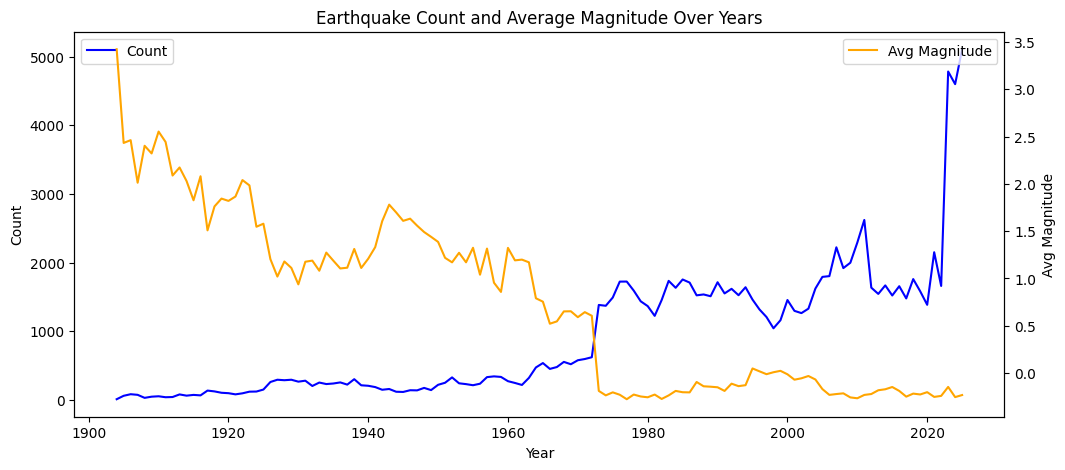

In [30]:
# Time series of earthquake counts and average magnitude by year
plt.figure(figsize=(12,5))
ax = df.groupby('Year').size().plot(label='Count', color='blue')
ax2 = ax.twinx()
df.groupby('Year')[magnitude_col].mean().plot(ax=ax2, color='orange', label='Avg Magnitude')
ax.set_ylabel('Count')
ax2.set_ylabel('Avg Magnitude')
ax.set_title('Earthquake Count and Average Magnitude Over Years')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.show()

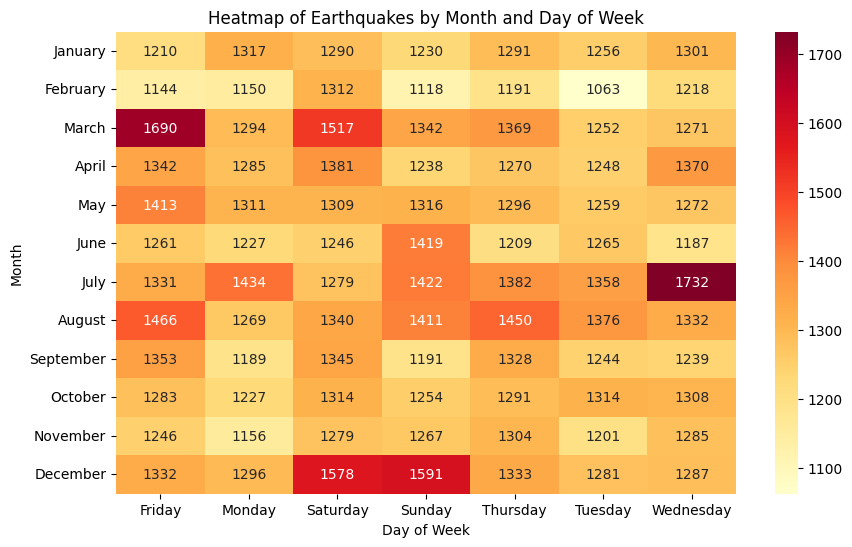

In [31]:
#  Heatmap of earthquakes by Month and DayOfWeek
heat_data = df.groupby(['Month','DayOfWeek']).size().unstack(fill_value=0)
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']
heat_data = heat_data.reindex(month_order)

plt.figure(figsize=(10,6))
sns.heatmap(heat_data, cmap='YlOrRd', annot=True, fmt='d')
plt.title('Heatmap of Earthquakes by Month and Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Month')
plt.show()

In [32]:
print("\nYearly Mean Magnitude:")
print(temporal_summary['Year'])

if damage_col:
    print("\nYearly Mean Damage Potential:")
    print(temporal_summary['Year_damage'])


Yearly Mean Magnitude:
Year
1904    3.424619
1905    2.433381
1906    2.462752
1907    2.012222
1908    2.403293
          ...   
2021   -0.253093
2022   -0.242423
2023   -0.147624
2024   -0.255237
2025   -0.233389
Name: mag, Length: 122, dtype: float64

Yearly Mean Damage Potential:
Year
1904    10.000000
1905    10.000000
1906     9.984457
1907     9.959922
1908    10.000000
          ...    
2021     9.571241
2022     9.445189
2023     9.393469
2024     9.361794
2025     9.619677
Name: damage_potential, Length: 122, dtype: float64


#### Task 2: Geographical Distribution Analysis
Explore spatial patterns of earthquake epicenters

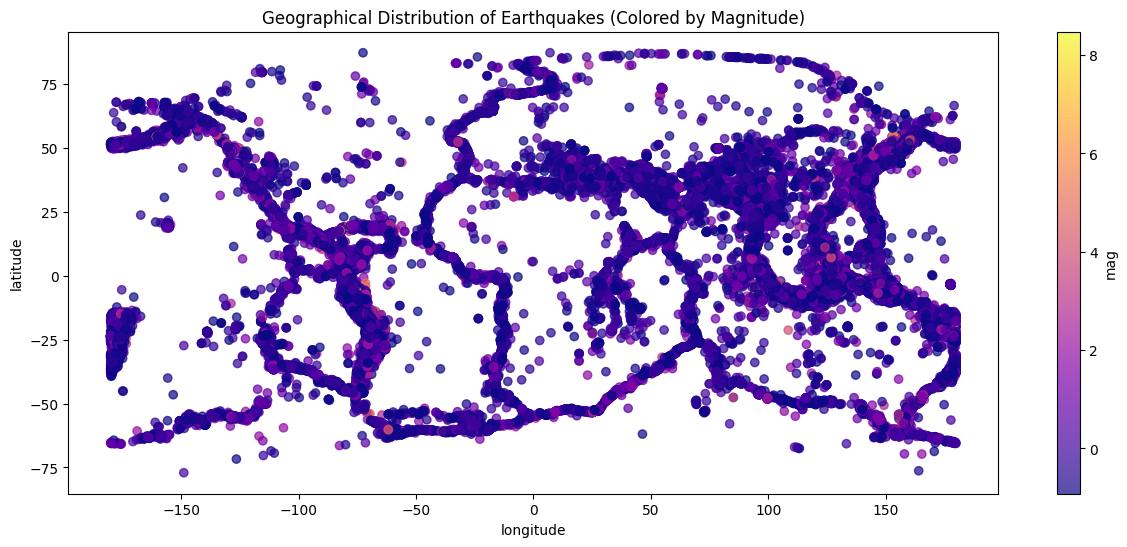

In [33]:
# Create scatter plot for latitude vs longitude colored by magnitude
plt.figure(figsize=(15, 6))
scatter = plt.scatter(
    df['longitude'], 
    df['latitude'], 
    c=df['mag'], 
    cmap='plasma', 
    alpha=0.7
)

plt.colorbar(scatter, label='mag')
plt.title('Geographical Distribution of Earthquakes (Colored by Magnitude)')
plt.xlabel('longitude')
plt.ylabel('latitude')
plt.show()

In [ ]:
# Create scatter plot for latitude vs longitude colored by damage potential

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df['longitude'], 
    df['latitude'], 
    c=df['damage_potential'], 
    cmap='coolwarm', 
    alpha=0.7
)

plt.colorbar(scatter, label='Damage Potential')
plt.title('Geographical Distribution of Earthquakes (Colored by Damage Potential)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()